In [2]:
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
import file_utils
from file_utils import readData, float2latex
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Aug2025/"

colors = ["darkorange", "crimson", "#2544D0", "olive", "orangered", "#2544D0", "k"]

Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 1e-3 1.0 0.8364 0.9771 0.01735
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 1e-2 1.0 0.7677 0.9757 0.01946
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 2e-2 1.0 0.742 0.9745 0.02049
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 3e-2 1.0 0.5903 0.9711 0.02865
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 4e-2 1.0 0.4261 0.9704 0.03764
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 5e-2 1.0 0.2122 0.6741 0.23221
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 6e-2 0.9758 0.1966 0.4069 0.07808
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 7e-2 0.7466 0.1678 0.3447 0.06165
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 8e-2 0.5667 0.1471 0.2947 0.05053
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 9e-2 0.4493 0.1373 0.2563 0.04068
Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 10e-2 0.4046 0.1228 0.2293 0.034


[(0.0, 1.0)]

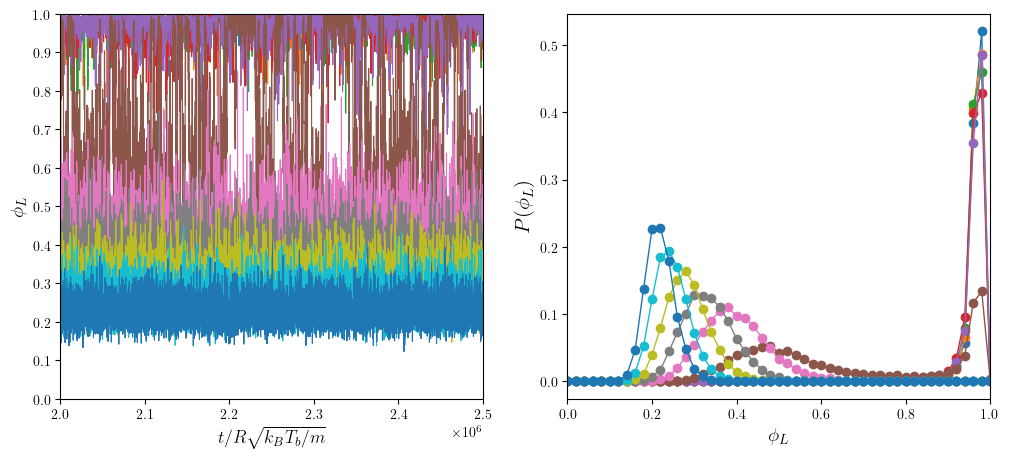

In [10]:
# Last modified : 17.06.25
# ax1 : Plot the lane order parameter as a function of time
# ax2 : Plot the distribution of the order parameter

tau_list = ["1e-3", "1e-2", "2e-2", "3e-2", "4e-2", "5e-2", "6e-2", "7e-2", "8e-2", "9e-2", "10e-2"]

# Params for time series
eq_steps = 1e7
Nevery = 1
dt = [5e-5] + [5e-4] * (len(tau_list) - 1)
dt = 5e-4

# Params for probability distribution
xmax = 1.0
nBins = 50
binW = (xmax - 0)/nBins

fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (12, 5))
plt.ticklabel_format(style = "sci", axis = 'x', scilimits = (0,0))

for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "Aug2025", "Fd100", "tau_{nr}".format(nr = tau_list[i]), "laneOrder.dat")
    [[step, order], _] = readData(fpath, 1)

    # ax1 : time series
    time = [(j-eq_steps)*dt for j in step[0::Nevery]]
    order = order[0::Nevery]
    ax1.plot(time, order, "-", lw = 0.8, label = r"${tau}$".format(tau = tau_list[i]))

    [[step, order], _] = readData(fpath, 1)

    avg_order = sum(order)/len(order)
    var = [(j - avg_order)**2 for j in order]
    var = sum(var)/(len(var) - 1)

    print("Lane order statistics: nr, Max, Min, Mean, Std. Dev. : {nr} {Max} {Min} {avg} {std}".format(nr = tau_list[i],
                                                                                                Max = round(max(order), 4), 
                                                                                                Min = round(min(order), 4), 
                                                                                                avg = round(avg_order, 4), 
                                                                                                std = round(np.sqrt(var), 5)))
    # ax2 : distribution of phi
    phi = np.linspace(0, xmax, nBins + 1)
    Bins = np.zeros(nBins + 1)

    for val in order:
        id = m.floor(val/binW)
        Bins[id] += int(1)

    totalCount = sum(Bins)
    
    for j in range(len(Bins)):
        Bins[j] /= (totalCount)

    ax2.plot(phi, Bins, "o-", lw = 1, label = r"${tau}$".format(tau = tau_list[i]))

ax1.set(xlim = (2.0e6, 2.5e6), ylim = (0, 1))
ax1.set_xlabel(r"$t/R\sqrt{k_BT_b/m}$", fontsize = 13)
ax1.set_ylabel(r"$\phi_L$", fontsize = 14)
ax1.set_xticks(np.arange(2.0e6, 2.55e6, 1e5))
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.set_xlabel(r"$\phi_L$", fontsize = 14)
ax2.set_ylabel(r"$P(\phi_L)$", fontsize = 15)
ax2.set(xlim = (0, xmax))

# fig.savefig(os.path.join(figpath, "nr38_gamma1e3_laneOrderDist.png"), dpi = 500, bbox_inches = "tight")

In [ ]:
# Plot potential energy and laneOrder parameter of the system as a function of time

nr_list = [26, 27]
D = ["5e-4", "5e-3"]
month = ["May2025", "Apr2025", "May2025", "Apr2025"]

eq_steps = 1e7
dt = 5e-4
Nevery = 50

fig3, ax3 = plt.subplots(2, 1, figsize = (6, 6))

fpath = os.path.join("//media/ashwin/One Touch/ashwin_md/lane", month[0], "lmp", "Data{nr}".format(nr = nr_list[0]), "thermo.dat")
[[step, pe], _] = readData(fpath, 1)
time = [(i-eq_steps)*dt for i in step]
ax3[0].plot(time[0::Nevery], pe[0::Nevery], "-", lw = 0.5, label = D[0])

fpath = os.path.join("//media/ashwin/One Touch/ashwin_md/lane", month[0], "lmp", "Data{nr}".format(nr = nr_list[1]), "thermo.dat")
[[step, T, pe, ke, te], _] = readData(fpath, 1)
time = [(i-eq_steps)*dt for i in step]
ax3[0].plot(time[0::Nevery], pe[0::Nevery], "-", lw = 0.5, label = D[1])

for i in range(len(nr_list)):
    fpath = os.path.join("//media/ashwin/One Touch/ashwin_md/lane", month[0], "lmp", "Data{nr}".format(nr = nr_list[i]), "laneOrder.dat")
    [[time, order], _] = readData(fpath, 1)
    
    ax3[1].plot(time[0::Nevery], order[0::Nevery], "-", lw = 0.5, label = D[i])

ax3[0].set(xlim = (-5e4, max(time)))
ax3[0].set_ylim(bottom = 0)
ax3[1].set(xlim = (-5e4, max(time)), ylim = (0, 1.1))

ax3[0].set_ylabel(r"$U \sigma/k_BT$", fontsize = 11)
ax3[1].set_ylabel(r"$\phi_L$", fontsize = 11)

for i in ax3:
    i.set_xlabel(r"$t/\sigma\sqrt{k_BT/m}$", fontsize = 10)
    i.set_xticks(np.arange(0, 5.5e6, 0.5e6))
    i.legend(title = r"D$^*$")

ax3[0].set_title(r"$F_d^* = 90$", fontsize = 12, loc = "left")
plt.tight_layout()
# fig3.savefig(os.path.join(figpath, "order1.png"), dpi = 500, bbox_inches = "tight")

10000 0.94718079 0.001453948622130913

n_blk =  [2, 4, 5, 8, 10, 16, 20, 25, 40, 50, 80, 100, 125, 200, 250, 400, 500, 625, 1000, 1250, 2000, 2500, 5000] 
tau_blk =  [5000, 2500, 2000, 1250, 1000, 625, 500, 400, 250, 200, 125, 100, 80, 50, 40, 25, 20, 16, 10, 8, 5, 4, 2]

SEM = 0.03761421623179976 0.037913371050211


Text(0, 0.5, '$\\sigma^2 (\\langle\\phi\\rangle_{blk})$')

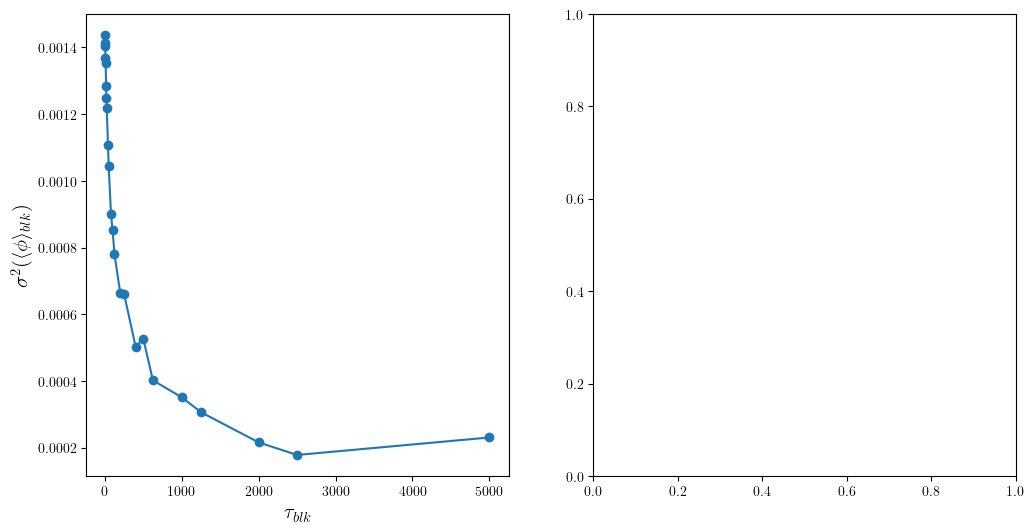

In [3]:
# Compute Standard Error of Mean (SEM) for a data set

fpath = os.path.join(dirpath, "Pe90", "Data39", "laneOrder.dat")
[[step ,order], _] = readData(fpath, 1)
order = order[1:]

tau_run = len(order)
run_avg = sum(order)/tau_run
sample_var = sum([(i - run_avg)**2 for i in order])
sample_var /= (tau_run - 1)

print(tau_run, run_avg, sample_var)

n_blk = []
tau_blk = []

for i in range(2, 5001, 1):
    if(tau_run%i == 0):
        n_blk.append(i)
        tau_blk.append(int(tau_run/i))

tau_blk_inv = [(1/i) for i in tau_blk]
        
print("\nn_blk = ", n_blk, "\ntau_blk = ", tau_blk)

blk_var = []
s = []
for i in range(len(n_blk)):
    blk_avg = np.zeros(n_blk[i])

    for blk in range(n_blk[i]):
        data = order[int(blk*tau_blk[i]):int((blk+1)*tau_blk[i])]
        blk_avg[blk] = sum(data)/len(data)

    total = 0
    for blk in range(n_blk[i]):
        total += (blk_avg[blk] - run_avg)**2

    blk_var.append(total/(n_blk[i]-1))
    s.append(blk_var[i]*tau_blk[i]/sample_var)
    
pos = len(blk_var)-1
print("\nSEM =", m.sqrt(blk_var[pos-1]), m.sqrt(blk_var[pos]))

fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (12, 6)) 
ax1.plot(tau_blk, blk_var, "o-")
ax1.set_xlabel(r"$\tau_{blk}$", fontsize = 15)
ax1.set_ylabel(r"$\sigma^2 (\langle\phi\rangle_{blk})$", fontsize = 15)
# ax1.set_ylim(top = 0.001)

# ax2.plot(tau_blk, s, "o-")
# ax2.set_xlabel(r"$\tau_{blk}$", fontsize = 15)
# ax2.set_ylabel(r"$s(\tau_{blk})$", fontsize = 15)

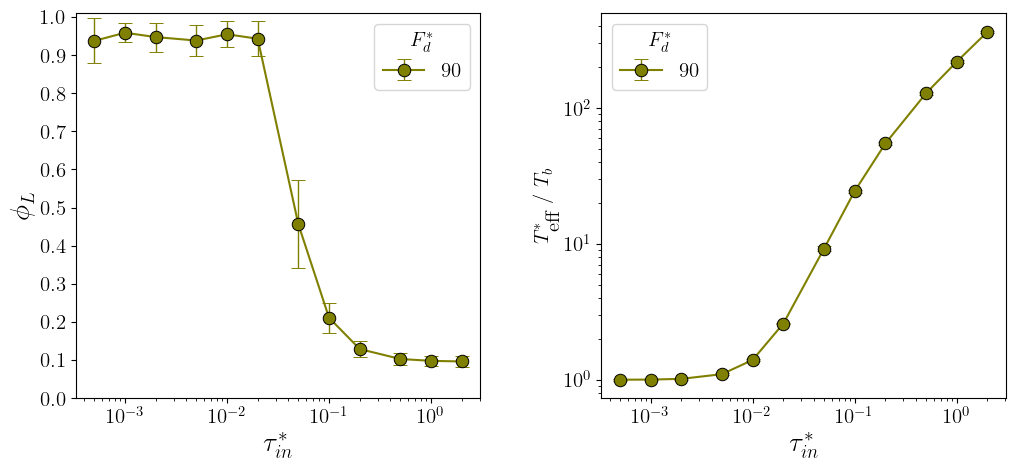

In [42]:
# Plot time-averaged lane order parameter and effective temp. plotted with 1 standard deviation
# Last modified : 29.06.25

fs = "full"
ms = 9
mew = 0.7

fpath = os.path.join(dirpath, "Pe90", "avgOrder.dat")
[data, _] = readData(fpath, 1)

nr = data[0]
tau = data[1]
max_val = data[2]
min_val = data[3]
avg = data[4]
std_dev = data[5]

yerr = [[], []]
for i in range(len(nr)):
    yerr[0].append(abs(min_val[i] - avg[i]))
    yerr[1].append(abs(max_val[i] - avg[i]))

fig7, ax7 = plt.subplots(1, 2, figsize = (12, 5))
ax7[0].errorbar(tau, avg, yerr = std_dev, xerr = None, fmt = "-o", ecolor = colors[3], elinewidth = 1, capsize = 5,
             color = colors[3], ms = ms, mec = "k", mew = mew, fillstyle = fs, label = r"$90$")

ax7[0].set_xscale('log')

fpath = os.path.join(dirpath, "Pe90", "avgTemp.dat")
[[nr, tau, avg, sem], _] = readData(fpath, 1)

ax7[1].errorbar(tau, avg, yerr = sem, xerr = None, fmt = "-o", ecolor = colors[3], elinewidth = 1, capsize = 5,
             color = colors[3], ms = ms, mec = "k", mew = mew, fillstyle = fs, label = r"$90$")

ax7[1].set_xscale('log')
ax7[1].set_yscale('log')

ax7[0].set(ylim = (0, 1.01))
ax7[0].set_yticks(np.arange(0, 1.1, 0.1))
ax7[0].set_xlabel(r"$\tau_{in}^*$", fontsize = 20)
ax7[0].set_ylabel(r"$\phi_L$", fontsize = 20)
ax7[0].tick_params(axis='both', which='major', labelsize = 15)
leg = ax7[0].legend(title = r"$F_d^*$", fontsize = 15)
leg.get_title().set_fontsize("15")

ax7[1].set_xlabel(r"$\tau_{in}^*$", fontsize = 20)
ax7[1].set_ylabel(r"$T_{\textrm{eff}}^*~/~T_b$", fontsize = 15)
ax7[1].tick_params(axis='both', which='major', labelsize = 15)
leg = ax7[1].legend(title = r"$F_d^*$", fontsize = 15)
leg.get_title().set_fontsize("15")

plt.subplots_adjust(wspace = 0.3)

# fig7.savefig(os.path.join(figpath, "Phi_gamma_Fd90_bounds_SEM.png"), dpi = 500, bbox_inches = "tight")

0.2
0.25


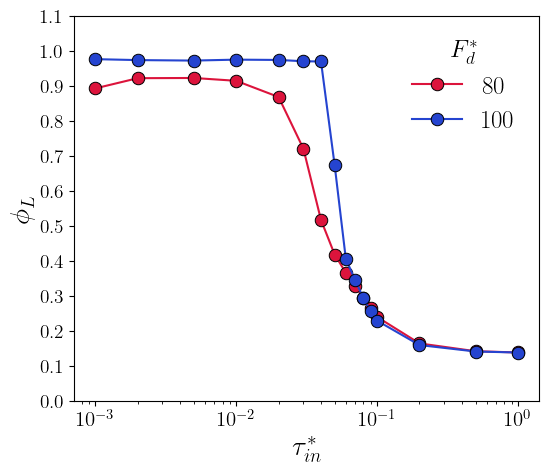

In [6]:
# Plot time-averaged lane order parameter for varying tau_in*
# Last modified : 01.07.25

colors = ["crimson", "#2544D0", "olive", "orangered", "#2544D0", "k", "darkorange"]

fs = "full"
ms = 9
mew = 0.7

Fd_list = [80, 100]

fig7, ax7 = plt.subplots(figsize = (6, 5))

# ax7.axvline(x = 0.01, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 1)
# ax7.axvline(x = 0.1, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 1)

for i in range(len(Fd_list)):

    fpath = os.path.join(dirpath, "June_July2025", "Pe{pe}".format(pe = Fd_list[i]), "avgOrder.dat")
    [data, _] = readData(fpath, 1)

    # for j in range(len(data)):
    #     data[j] = data[j][1:-]
    
    tau = data[1]
    avg_order = data[4]
    std_dev = data[5]

    Stk = [(Fd_list[i]*Tau*Tau) for Tau in tau]

    print(Stk[7])

    ax7.errorbar(tau, avg_order, yerr = None, xerr = None, fmt = "-o", ecolor = colors[i], elinewidth = 1, capsize = 5,
                 color = colors[i], mec = "k", ms = ms, mew = mew, fillstyle = "full", label = r"${pe}$".format(pe = Fd_list[i]))

ax7.set_xscale("log")

ax7.set(ylim = (0, 1.01))
ax7.set_yticks(np.arange(0, 1.11, 0.1))
# ax7.set_xlabel(r"$St$", fontsize = 20)
ax7.set_xlabel(r"$\tau_{in}^*$", fontsize = 20)
ax7.set_ylabel(r"$\phi_L$", fontsize = 20)
ax7.tick_params(axis = "x", which = "major", labelsize = 15)
ax7.tick_params(axis = "y", which = "major", labelsize = 14)
leg = ax7.legend(title = r"$F_d^*$", fontsize = 18, loc = "upper right", frameon = False)
leg.get_title().set_fontsize("18")

# fig7.text(0.06, 0.85, r"$(a)$", fontsize = 15)
# fig7.text(0.5, 0.85, r"$(b)$", fontsize = 15)

# fig7.savefig(os.path.join(figpath, "Phi_Fd_80_100.png"), dpi = 500, bbox_inches = "tight")

[79.79253939756633, 79.04357276948917, 74.25283088917766, 61.02677549774964, 35.90503119249585, 22.013703530447703, 15.035333032626673, 10.909884355225834, 8.309271069195454, 6.606274309024997, 5.439882498538031, 4.616325635610337, 4.012941737102154, 1.7576777561485764, 0.741617634925741, 0.4320267943017826]
[99.59167413604223, 98.11616954474097, 89.03133903133903, 66.8359844940516, 33.513187439257344, 18.32105822432304, 11.2173015659353, 8.31545510485789, 6.811664293936937, 5.448492674501599, 4.532393012862931, 3.88914384387421, 3.4082814422483754, 1.5423696659073065, 0.6676944710223938, 0.3921728572459426]


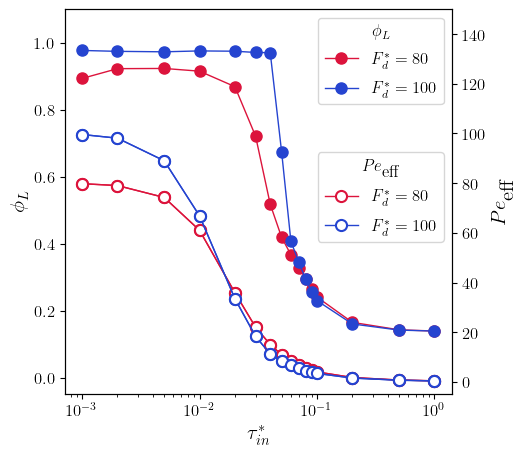

In [13]:
# Plot of lane order parameter and effective Peclet number vs inertial time

ms = 8
lw = 1.0
mew = 1.0
fs = "none"

Fd_list = [80, 100]
markers = ["o", "o", "s"]
colors = ["crimson", "#2544D0", "olive", "orangered", "#2544D0", "k", "darkorange"]

fig8, ax8 = plt.subplots(figsize = (5, 5))
ax8b = ax8.twinx()

# for i in range(len(Fd_list)):
#     ax8b.axhline(y = Fd_list[i], xmin = 0, xmax = 1, ls = "--", color = colors[i], lw = lw)

points1 = []
points2 = []
for i in range(len(Fd_list)):
    fpath = os.path.join(dirpath, "June_July2025", "Pe{Fd}".format(Fd = Fd_list[i]), "avgOrder.dat")

    [data, _] = readData(fpath, 1)
    tau = data[1]
    order = data[4]

    fpath = os.path.join(dirpath, "June_July2025", "Pe{Fd}".format(Fd = Fd_list[i]), "avgTemp.dat")

    [data, _] = readData(fpath, 1)
    temp = data[4]
    temp_inv = [(1/T) for T in temp]

    Pe = [Fd_list[i]/j for j in temp]
    print(Pe)

    point1, = ax8.semilogx(tau, order, "-", marker = markers[i], lw = lw, ms = ms, color = colors[i], 
                           label = r"$F_d^* = {Fd}$".format(Fd = Fd_list[i]), mew = mew)
    points1.append(point1)
    
    point2, = ax8b.semilogx(tau, Pe, "-", marker = markers[i], lw = lw, ms = ms, color = colors[i], 
                            label = r"$F_d^* = {Fd}$".format(Fd = Fd_list[i]), mec = colors[i], mew = 1.5, mfc = "white")
    points2.append(point2)
    ax8b.semilogx(tau, Pe, marker = markers[i], lw = lw, ms = ms, color = colors[i], mec = colors[i], mew = 1.5, mfc = "white")

# ax8b.axhline(y = 10, xmin = 0, xmax = 1, ls = "--", color = "k", lw = lw)

ax8.set(ylim = (-0.05, 1.1))
ax8.set_xlabel(r"$\tau_{in}^*$", fontsize = 15)
ax8.set_ylabel(r"$\phi_L$", fontsize = 15)
ax8.tick_params(axis = "both", which = "major", labelsize = 12)
leg1 = ax8.legend(handles = points1, title = r"$\phi_L$", frameon = True, fontsize = 12, labelspacing = 0.8)
leg1.get_title().set_fontsize("12")

ax8b.set(ylim = (-5, 150))
ax8b.set_ylabel(r"$Pe_{\textrm{eff}}$", fontsize = 15)
ax8b.tick_params(axis = "both", which = "major", labelsize = 12)
leg2 = ax8b.legend(handles = points2, title = r"$Pe_{\textrm{eff}}$", frameon = True, fontsize = 12, labelspacing = 0.8,
                  bbox_to_anchor = (1, 0.65))
leg2.get_title().set_fontsize("12")

# fig8.savefig(os.path.join(figpath, "Phi_Pe_tau.png"), dpi = 600, bbox_inches = "tight")

0.9688


[(0.9, 1.0)]

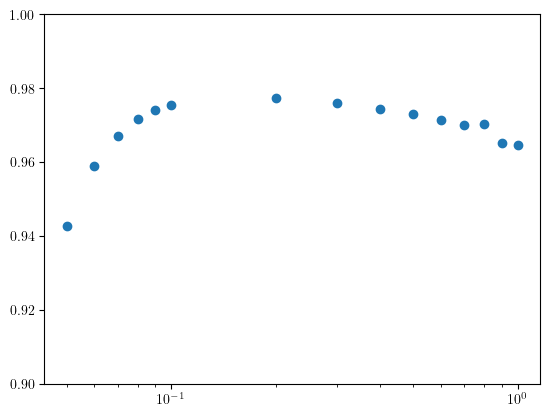

In [14]:
# Comparison of the avg. lane order parameter for varying slab widths (Params: Fd = 100, tau = 5e-3)

order = [0.964768, 0.965199, 0.970288, 0.970110, 0.971380, 0.972951, 0.974460, 0.976084, 0.977259, 0.975360, 0.974024, 0.971588, 0.967014, 
         0.958844, 0.942660]
slabW = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.09, 0.08, 0.07, 0.06, 0.05]

avg = round(sum(order)/len(order), 4)
print(avg)

fig, ax = plt.subplots()
ax.semilogx(slabW, order, "o")
ax.set(ylim = (0.9, 1))